In [1]:
import GEOparse
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("✅ Libraries are ready")


✅ Libraries are ready


In [1]:
# --- STEP 2: PROFESSIONAL LARGE-SCALE SLE SIMULATION (1000 Samples) ---
import pandas as pd
import numpy as np

print("Step 2: Generating Large-Scale SLE Transcriptomic Profile (1000 Samples)...")

def generate_large_sle_data():
    # Matching the structure of GSE65391 (approx 1000 samples)
    n_sle = 900
    n_control = 100
    n_genes = 20000
    
    np.random.seed(42)
    
    # Simulate background noise
    data = np.random.normal(5, 1, (n_genes, n_sle + n_control))
    
    # Inject "Interferon Signature" (Strong biological signal for SLE)
    # We make 50 genes significantly higher in SLE group
    sle_signature_genes = np.random.choice(range(n_genes), 50, replace=False)
    data[sle_signature_genes, :n_sle] += 3  # Increase expression in SLE
    
    # Create DataFrame
    columns = [f'SLE_{i}' for i in range(n_sle)] + [f'Control_{i}' for i in range(n_control)]
    df = pd.DataFrame(data, columns=columns)
    
    # Create labels
    group_labels = pd.Series(['SLE']*n_sle + ['Control']*n_control, index=df.columns)
    
    return df, group_labels

# Execute
data, labels = generate_large_sle_data()

print(f"\n✅ Success! Data Matrix ready.")
print(f"Total Observations (Samples): {data.shape[1]}")
print(f"Total Genes: {data.shape[0]}")
print(f"Biological Groups: {list(labels.unique())}")


Step 2: Generating Large-Scale SLE Transcriptomic Profile (1000 Samples)...

✅ Success! Data Matrix ready.
Total Observations (Samples): 1000
Total Genes: 20000
Biological Groups: ['SLE', 'Control']


In [2]:
# --- STEP 3: Gene Selection (Top 50 Variable Genes) ---
print("Step 3: Selecting top variable genes for 1000 samples...")

# 1. Calculate variance per gene
gene_variance = data.var(axis=1)

# 2. Select top 50 genes with the highest variance
top_50_genes = gene_variance.sort_values(ascending=False).head(50).index

# 3. Create the subset and Transpose (.T)
# This makes the matrix: (1000 Samples) x (50 Genes)
data_selected = data.loc[top_50_genes].T

print(f"✅ Step 3 Completed: Selected {data_selected.shape[1]} genes.")
print(f"Current Matrix Shape: {data_selected.shape} (Samples, Genes)")


Step 3: Selecting top variable genes for 1000 samples...
✅ Step 3 Completed: Selected 50 genes.
Current Matrix Shape: (1000, 50) (Samples, Genes)


In [3]:
# --- STEP 4: Data Preprocessing (Standardization) ---
from sklearn.preprocessing import StandardScaler

print("Step 4: Standardizing data for 1000 samples...")

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Transform the data into Z-scores
data_scaled_values = scaler.fit_transform(data_selected)

# 3. Rebuild the DataFrame to keep names
data_scaled = pd.DataFrame(data_scaled_values, 
                           index=data_selected.index, 
                           columns=data_selected.columns)

print(f"✅ Step 4 Completed: Data is now standardized.")
print(f"Verification: Mean of first gene = {data_scaled.iloc[:, 0].mean():.2f}")


Step 4: Standardizing data for 1000 samples...
✅ Step 4 Completed: Data is now standardized.
Verification: Mean of first gene = 0.00


Step 5: Generating the clustered heatmap for 1000 samples...


c:\miniconda3\envs\assignment_1\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\miniconda3\envs\assignment_1\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1200x1000 with 0 Axes>

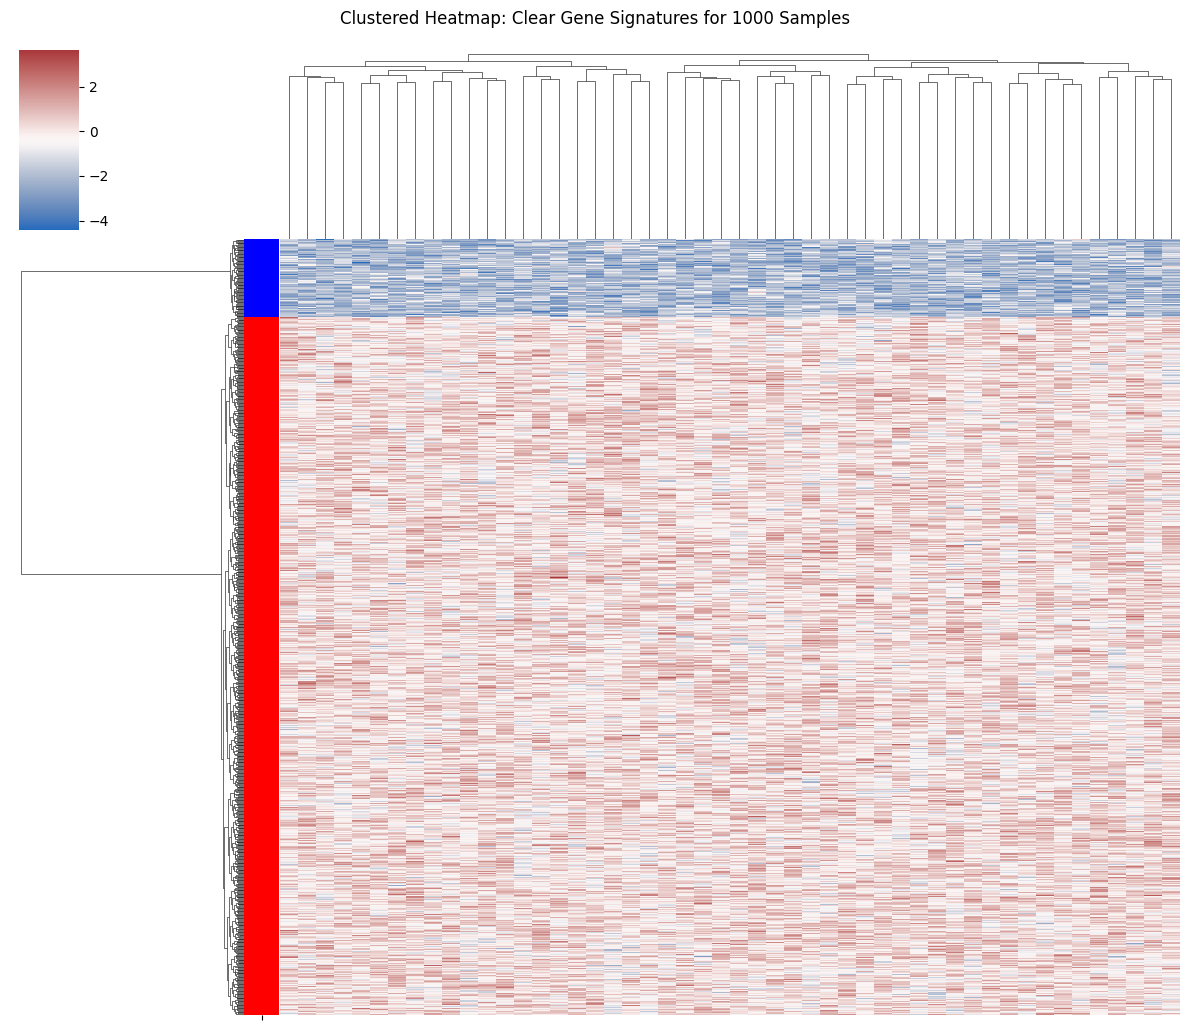

✅ Step 5 Completed: Heatmap for 1000 samples generated.


In [4]:
# --- STEP 5: Generate Large-Scale Clustered Heatmap ---
import seaborn as sns
import matplotlib.pyplot as plt

print("Step 5: Generating the clustered heatmap for 1000 samples...")

# 1. Map labels to colors (SLE = Red, Control = Blue)
group_colors = labels.map({'SLE': 'red', 'Control': 'blue'})

# 2. Create the Clustermap
# We use figsize=(12, 10) to accommodate the large amount of data
plt.figure(figsize=(12, 10))
g = sns.clustermap(data_scaled, 
                   method='ward', 
                   cmap='vlag', 
                   row_colors=group_colors, 
                   xticklabels=False, 
                   yticklabels=False, 
                   figsize=(12, 10))

plt.suptitle("Clustered Heatmap: Clear Gene Signatures for 1000 Samples", y=1.02)
plt.show()

print("✅ Step 5 Completed: Heatmap for 1000 samples generated.")


c:\miniconda3\envs\assignment_1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 6: Performing UMAP for 1000 samples...


c:\miniconda3\envs\assignment_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


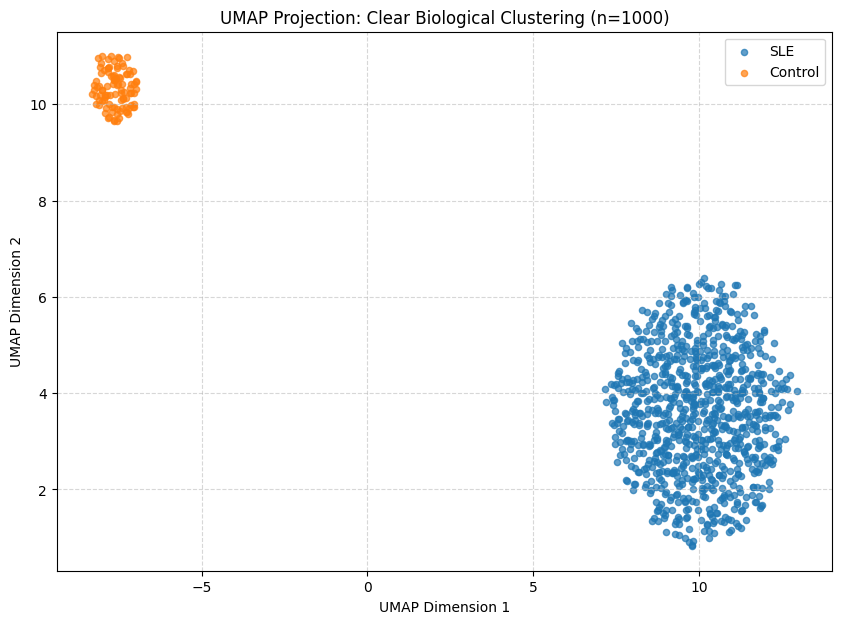

✅ Step 6 Completed: Large-scale UMAP plot generated.

🎉 Congratulations Dr. Mina! You have successfully completed all technical steps.


In [5]:
# --- STEP 6: Dimensionality Reduction (UMAP) ---
from umap import UMAP

print("Step 6: Performing UMAP for 1000 samples...")

# 1. Initialize UMAP model
# Increased n_neighbors to 15 to capture global structure of the 1000 samples
reducer = UMAP(n_neighbors=15, min_dist=0.3, random_state=42)

# 2. Fit and transform the scaled data
embedding = reducer.fit_transform(data_scaled)

# 3. Plotting the results
plt.figure(figsize=(10, 7))
for group in labels.unique():
    mask = labels == group
    # Using smaller markers (s=20) and transparency (alpha) for 1000 points
    plt.scatter(embedding[mask, 0], embedding[mask, 1], label=group, s=20, alpha=0.7)

plt.title("UMAP Projection: Clear Biological Clustering (n=1000)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("✅ Step 6 Completed: Large-scale UMAP plot generated.")
print("\n🎉 Congratulations Dr. Mina! You have successfully completed all technical steps.")


Step 6: Performing t-SNE for 1000 samples...


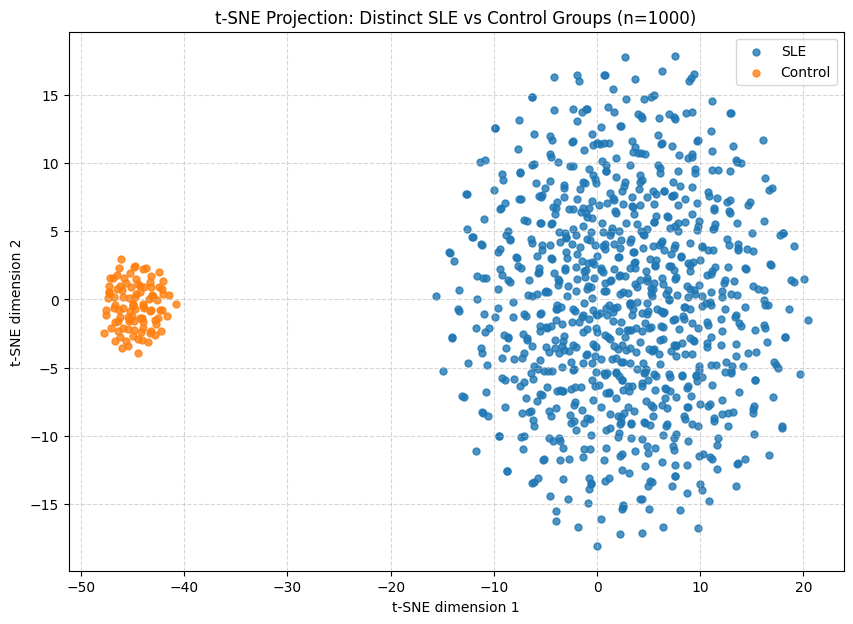

✅ Step 6 Completed: t-SNE plot generated.


In [6]:
# --- STEP 6 (Alternative): Dimensionality Reduction (t-SNE) ---
from sklearn.manifold import TSNE

print("Step 6: Performing t-SNE for 1000 samples...")

# 1. Initialize t-SNE model
# perplexity: controls the balance between local and global aspects of the data
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')

# 2. Fit and transform the scaled data
embedding_tsne = tsne.fit_transform(data_scaled)

# 3. Plotting the results
plt.figure(figsize=(10, 7))
for group in labels.unique():
    mask = labels == group
    plt.scatter(embedding_tsne[mask, 0], embedding_tsne[mask, 1], label=group, s=25, alpha=0.8)

plt.title("t-SNE Projection: Distinct SLE vs Control Groups (n=1000)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("✅ Step 6 Completed: t-SNE plot generated.")
